# Earthquake Baseline Model Training
This notebook trains baseline models (Logistic Regression and Decision Tree) using the preprocessed earthquake data.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Preprocessed Data

In [3]:
df = pd.read_csv("earthquake_processed.csv")
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (1256, 8)


,magnitude,depth,cdi,mmi,sig,alert,depth_mag_ratio,alert_encoded
0,-0.143689,-0.352519,0.463323,0.060151,0.166882,green,-0.348561,0
1,-0.380035,-0.248606,-1.319015,-2.140313,-0.362421,green,-0.242449,0
2,-0.143689,4.984834,-1.764599,-2.873801,-0.041631,green,4.949339,0
3,0.565348,-0.135246,-0.873430,-1.406825,1.209449,green,-0.145434,0
4,-1.089073,5.409933,-3.101352,-3.607289,-1.404988,green,5.679250,0


## 3. Prepare Features and Target

In [4]:
# Define features and target
X = df[['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'depth_mag_ratio']]
y = df['alert_encoded']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1004, 6)
Testing set size: (252, 6)


## 4. Logistic Regression Model

In [5]:
# Initialize and train the model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
lr_preds = lr_model.predict(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression MAE: {lr_mae:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.6746
Logistic Regression MAE: 0.6270

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79        73
           1       0.67      0.45      0.54        64
           2       0.72      0.87      0.79        63
           3       0.46      0.62      0.53        52

    accuracy                           0.67       252
   macro avg       0.68      0.67      0.66       252
weighted avg       0.69      0.67      0.67       252



## 5. Decision Tree Model

In [6]:
# Initialize and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
dt_preds = dt_model.predict(X_test)

# Evaluate
dt_accuracy = accuracy_score(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree MAE: {dt_mae:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.8690
Decision Tree MAE: 0.2976

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        73
           1       0.88      0.94      0.91        64
           2       0.95      0.92      0.94        63
           3       0.75      0.83      0.79        52

    accuracy                           0.87       252
   macro avg       0.87      0.87      0.87       252
weighted avg       0.87      0.87      0.87       252



## 6. Model Comparison

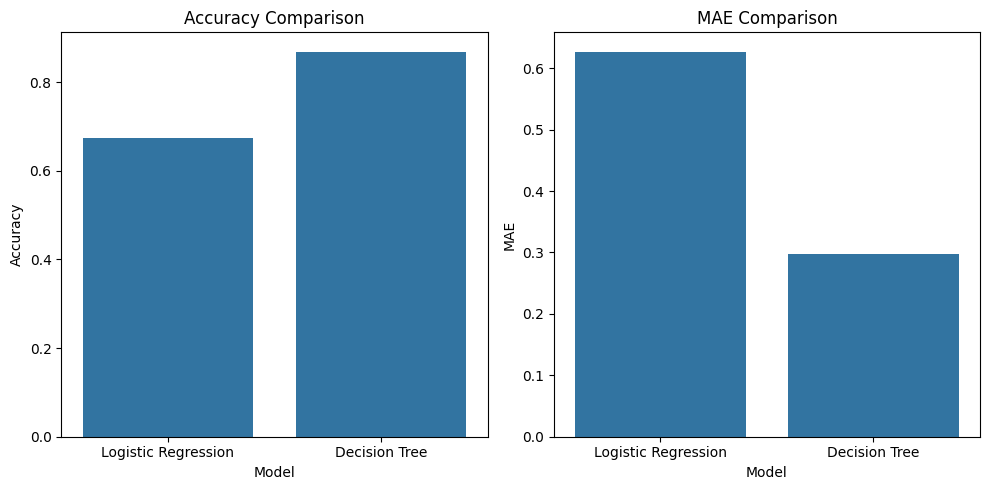

In [7]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [lr_accuracy, dt_accuracy],
    'MAE': [lr_mae, dt_mae]
})

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Accuracy Comparison')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='MAE', data=results)
plt.title('MAE Comparison')

plt.tight_layout()
plt.show()